# Entrega 1 — Análise Comparativa de Representações

**Ouvidoria Inteligente: triagem semântica de manifestações cidadãs**

Neste notebook, as 40 manifestações da base `manifestacoes.json` são representadas de três formas:

| Representação | Tipo | Ideia |
|---|---|---|
| Bag-of-Words (BoW) | esparsa | conta quantas vezes cada palavra aparece |
| TF-IDF | esparsa | pondera as palavras, dando mais peso às raras |
| Embeddings | densa | vetor que representa o significado da frase |

Em seguida, calculamos a similaridade de cosseno nos três pares pedidos no enunciado:

| Par | Descrição | O que esperamos |
|---|---|---|
| M003 × M017 | "buraco enorme na Av. Brasil" × "asfalto todo esburacado da avenida principal" | mesmo problema, palavras diferentes |
| M008 × M022 | "posto de saúde sem médico" × "falta atendimento no PSF" | mesmo problema, palavras diferentes |
| M008 × M031 | "posto de saúde sem médico" × "lâmpada queimada na praça" | problemas sem relação |

In [1]:
# Bibliotecas (as variáveis de ambiente escondem barras de progresso e avisos do download dos modelos)
import json
import os

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 120)

## 1. Carregando a base de manifestações

In [2]:
with open("manifestacoes.json", encoding="utf-8") as arquivo:
    manifestacoes = json.load(arquivo)

df = pd.DataFrame(manifestacoes)
df["tamanho"] = df["texto"].str.len()
textos = df["texto"].tolist()
indice = {id_: i for i, id_ in enumerate(df["id"])}

print(f"Total de manifestações: {len(df)}")
print(df["categoria_oficial"].value_counts().to_string())
df[["id", "data", "categoria_oficial", "tamanho", "texto"]].head(10)

Total de manifestações: 40
categoria_oficial
infraestrutura    9
meio ambiente     9
saúde             8
educação          7
segurança         7


,id,data,categoria_oficial,tamanho,texto
0,M001,2026-03-02,infraestrutura,119,"A rua Joaquim Nabuco, no bairro Torre, está completamente escura há duas semanas porque os postes pararam de funcionar."
1,M002,2026-03-02,saúde,135,A farmácia do posto de saúde do bairro Cristo está sem remédio para pressão há quase um mês. Minha mãe precisa do me...
2,M003,2026-03-03,infraestrutura,95,"Tem um buraco enorme na Av. Brasil, perto do mercado. Já vi duas motos caírem nele esta semana."
3,M004,2026-03-03,educação,129,"A escola municipal do Valentina está com o telhado da sala 3 cheio de goteiras. Quando chove, as crianças são mandad..."
4,M005,2026-03-04,infraestrutura,135,O semáforo do cruzamento da Rua Epitácio Pessoa com a Rua Rui Carneiro está piscando amarelo há três dias e quase ac...
5,M006,2026-03-05,segurança,134,Pedimos mais rondas policiais no bairro Mangabeira. Os moradores estão com medo de sair à noite depois de vários fur...
6,M007,2026-03-05,meio ambiente,145,Estão cortando árvores antigas na praça do bairro Bessa sem nenhuma placa de autorização. Gostaria de saber se isso ...
7,M008,2026-03-06,saúde,128,O posto de saúde do bairro Cristo está sem médico desde o começo do mês. As pessoas chegam cedo e voltam para casa s...
8,M009,2026-03-06,educação,104,Meu filho está sem professor de matemática desde fevereiro na escola municipal do bairro Cruz das Armas.
9,M010,2026-03-07,educação,144,Na escola municipal do bairro Alto do Mateus não está sendo servida merenda escolar há uma semana. As crianças ficam...


## 2. Stopwords em português

O scikit-learn só traz uma lista de stopwords em inglês (`stop_words="english"`). Passar `stop_words="portuguese"`, como aparece em alguns exemplos, gera erro. Por isso, usamos uma lista própria com as palavras mais comuns do português, que não ajudam a diferenciar um problema do outro.

In [3]:
STOPWORDS_PT = [
    "a", "o", "as", "os", "um", "uma", "uns", "umas", "de", "do", "da", "dos", "das",
    "em", "no", "na", "nos", "nas", "por", "pelo", "pela", "pelos", "pelas", "para", "pra",
    "com", "sem", "sobre", "entre", "até", "ao", "aos", "à", "às", "e", "ou", "mas", "que",
    "se", "como", "quando", "onde", "porque", "já", "não", "mais", "muito", "também", "só",
    "é", "são", "está", "estão", "foi", "ser", "ter", "tem", "há", "isso", "isto", "esse",
    "essa", "este", "esta", "eu", "ele", "ela", "eles", "elas", "nós", "me", "minha", "meu",
    "seu", "sua", "lhe", "todo", "toda", "todos", "todas", "outro", "outra", "vez",
]

## 3. Bag-of-Words (BoW)

In [4]:
bow = CountVectorizer(stop_words=STOPWORDS_PT)
X_bow = bow.fit_transform(textos)

print(f"Vocabulário: {len(bow.vocabulary_)} termos")
print(f"Matriz BoW: {X_bow.shape} (manifestações × termos)")
print(f"Densidade: {(X_bow.toarray() != 0).mean():.2%} das posições são diferentes de zero")

Vocabulário: 505 termos
Matriz BoW: (40, 505) (manifestações × termos)
Densidade: 3.49% das posições são diferentes de zero


## 4. TF-IDF

In [5]:
tfidf = TfidfVectorizer(stop_words=STOPWORDS_PT)
X_tfidf = tfidf.fit_transform(textos)

print(f"Matriz TF-IDF: {X_tfidf.shape}")

Matriz TF-IDF: (40, 505)


## 5. Embeddings (dois modelos multilíngues)

O enunciado sugere modelos multilíngues e pede a comparação de pelo menos dois. Usamos:

- `paraphrase-multilingual-MiniLM-L12-v2`: pequeno e rápido, com vetores de 384 dimensões;
- `paraphrase-multilingual-mpnet-base-v2`: maior e mais preciso, com vetores de 768 dimensões.

O modelo `BAAI/bge-small-pt-v1.5`, citado como alternativa, não foi encontrado no Hugging Face, que só tem as versões em inglês e chinês. Por isso, foi substituído pelo mpnet multilíngue.

Na primeira execução, os modelos são baixados da internet.

In [6]:
MODELOS = {
    "MiniLM": "paraphrase-multilingual-MiniLM-L12-v2",
    "mpnet": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
}

X_emb = {}
for apelido, nome in MODELOS.items():
    modelo = SentenceTransformer(nome)
    X_emb[apelido] = modelo.encode(textos, normalize_embeddings=True)
    print(f"{apelido}: matriz de embeddings {X_emb[apelido].shape}")

MiniLM: matriz de embeddings (40, 384)


mpnet: matriz de embeddings (40, 768)


## 6. Similaridade de cosseno nos pares pedidos

In [7]:
PARES = [
    ("M003", "M017", "mesmo problema (buraco na avenida)"),
    ("M008", "M022", "mesmo problema (posto sem médico)"),
    ("M008", "M031", "problemas diferentes (saúde × iluminação)"),
]


def cosseno_par(matriz, id_a, id_b):
    a, b = indice[id_a], indice[id_b]
    return float(cosine_similarity(matriz[a:a + 1], matriz[b:b + 1])[0, 0])


linhas = []
for id_a, id_b, relacao in PARES:
    linhas.append({
        "Par": f"{id_a} × {id_b}",
        "Relação": relacao,
        "BoW": cosseno_par(X_bow, id_a, id_b),
        "TF-IDF": cosseno_par(X_tfidf, id_a, id_b),
        "Emb. MiniLM": cosseno_par(X_emb["MiniLM"], id_a, id_b),
        "Emb. mpnet": cosseno_par(X_emb["mpnet"], id_a, id_b),
    })

tabela_pares = pd.DataFrame(linhas)
tabela_pares.style.format({c: "{:.3f}" for c in ["BoW", "TF-IDF", "Emb. MiniLM", "Emb. mpnet"]}).background_gradient(
    cmap="Greens", subset=["BoW", "TF-IDF", "Emb. MiniLM", "Emb. mpnet"], vmin=0, vmax=1
)

,Par,Relação,BoW,TF-IDF,Emb. MiniLM,Emb. mpnet
0,M003 × M017,mesmo problema (buraco na avenida),0.000,0.000,0.613,0.714
1,M008 × M022,mesmo problema (posto sem médico),0.081,0.068,0.689,0.679
2,M008 × M031,problemas diferentes (saúde × iluminação),0.081,0.018,0.179,0.330


In [8]:
for id_a, id_b, _ in PARES:
    print(f"{id_a}: {df.loc[indice[id_a], 'texto']}")
    print(f"{id_b}: {df.loc[indice[id_b], 'texto']}")
    print()

M003: Tem um buraco enorme na Av. Brasil, perto do mercado. Já vi duas motos caírem nele esta semana.
M017: O asfalto está todo esburacado na avenida principal. Tem uma cratera no meio da pista que já derrubou motociclistas e estraga os pneus dos carros.

M008: O posto de saúde do bairro Cristo está sem médico desde o começo do mês. As pessoas chegam cedo e voltam para casa sem consulta.
M022: Falta atendimento no PSF do Cristo. A unidade está sem doutor e a população volta sem ser atendida, só fazem curativo.

M008: O posto de saúde do bairro Cristo está sem médico desde o começo do mês. As pessoas chegam cedo e voltam para casa sem consulta.
M031: Tem uma lâmpada queimada na praça do bairro Jaguaribe. À noite fica tudo escuro perto do parquinho.



## 7. Por que as representações esparsas falham? Termos em comum

BoW e TF-IDF só enxergam semelhança quando os dois textos usam **as mesmas palavras**. A célula abaixo mostra quais termos, depois da remoção de stopwords, cada par tem em comum.

In [9]:
analisador = bow.build_analyzer()

for id_a, id_b, _ in PARES:
    termos_a = set(analisador(df.loc[indice[id_a], "texto"]))
    termos_b = set(analisador(df.loc[indice[id_b], "texto"]))
    comuns = sorted(termos_a & termos_b)
    print(f"{id_a} × {id_b}: {len(comuns)} termo(s) em comum → {comuns}")

M003 × M017: 0 termo(s) em comum → []
M008 × M022: 1 termo(s) em comum → ['cristo']
M008 × M031: 1 termo(s) em comum → ['bairro']


## 8. Comparação visual

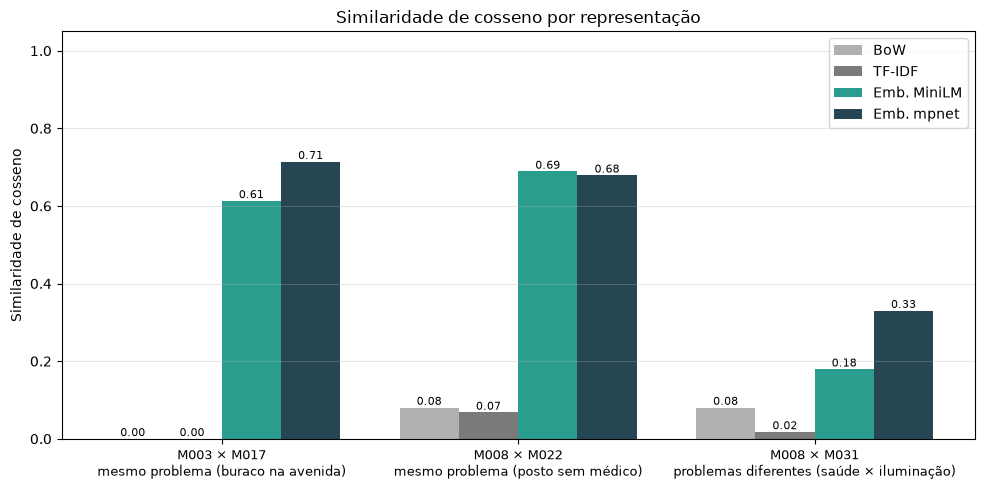

In [10]:
colunas = ["BoW", "TF-IDF", "Emb. MiniLM", "Emb. mpnet"]
cores = ["#b0b0b0", "#7a7a7a", "#2a9d8f", "#264653"]
x = np.arange(len(tabela_pares))
largura = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, (coluna, cor) in enumerate(zip(colunas, cores)):
    barras = ax.bar(x + (i - 1.5) * largura, tabela_pares[coluna], largura, label=coluna, color=cor)
    ax.bar_label(barras, fmt="%.2f", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(tabela_pares["Par"] + "\n" + tabela_pares["Relação"], fontsize=9)
ax.set_ylabel("Similaridade de cosseno")
ax.set_ylim(0, 1.05)
ax.set_title("Similaridade de cosseno por representação")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Visão geral: duplicatas reais × pares diferentes

Três pares são poucos para tirar conclusões. Então usamos o gabarito da base (campo `duplicata_de`) para comparar, em cada representação:

- a similaridade média entre as **6 duplicatas reais**;
- a similaridade média entre manifestações de **categorias diferentes**.

Quanto maior a distância entre as duas médias, melhor a representação separa "mesmo problema" de "assunto diferente".

In [11]:
pares_duplicados = [(indice[m["id"]], indice[m["duplicata_de"]]) for m in manifestacoes if m.get("duplicata_de")]
categorias = df["categoria_oficial"].tolist()
pares_diferentes = [
    (i, j) for i in range(len(df)) for j in range(i + 1, len(df)) if categorias[i] != categorias[j]
]

representacoes = {"BoW": X_bow, "TF-IDF": X_tfidf, "Emb. MiniLM": X_emb["MiniLM"], "Emb. mpnet": X_emb["mpnet"]}
resumo = []
for nome, matriz in representacoes.items():
    sim = cosine_similarity(matriz)
    media_dup = np.mean([sim[i, j] for i, j in pares_duplicados])
    media_dif = np.mean([sim[i, j] for i, j in pares_diferentes])
    resumo.append({
        "Representação": nome,
        "Média duplicatas reais": media_dup,
        "Média categorias diferentes": media_dif,
        "Separação (diferença)": media_dup - media_dif,
    })

pd.DataFrame(resumo).style.format({c: "{:.3f}" for c in ["Média duplicatas reais", "Média categorias diferentes", "Separação (diferença)"]})

,Representação,Média duplicatas reais,Média categorias diferentes,Separação (diferença)
0,BoW,0.248,0.039,0.209
1,TF-IDF,0.202,0.016,0.185
2,Emb. MiniLM,0.753,0.218,0.535
3,Emb. mpnet,0.807,0.289,0.518


## 10. Conclusão

| Par | Relação | BoW | TF-IDF | Emb. MiniLM | Emb. mpnet |
|---|---|---|---|---|---|
| M003 × M017 | mesmo problema | 0,000 | 0,000 | 0,613 | 0,714 |
| M008 × M022 | mesmo problema | 0,081 | 0,068 | 0,689 | 0,679 |
| M008 × M031 | problemas diferentes | 0,081 | 0,018 | 0,179 | 0,330 |

**BoW e TF-IDF** representam cada manifestação pelas palavras que ela contém e, por isso, só enxergam semelhança quando os textos repetem o mesmo vocabulário. M003 e M017 descrevem o mesmo buraco, mas não têm nenhum termo em comum ("buraco" × "esburacado", "Av." × "avenida"), e as duas representações dão similaridade **zero**. Pior: no BoW, a duplicata M008 × M022 e o par sem relação M008 × M031 recebem exatamente o mesmo valor (0,081), porque cada par compartilha uma única palavra que nada diz sobre o problema ("cristo" num caso, "bairro" no outro). O TF-IDF separa um pouco os dois (0,068 × 0,018) só porque "cristo" é uma palavra mais rara que "bairro", e não porque entendeu o assunto. Sinônimos, siglas (PSF × posto de saúde) e paráfrases ficam invisíveis, e os vetores são esparsos: só 3,5% das posições da matriz são diferentes de zero.

**Os embeddings** comparam significado. Os dois modelos dão valores altos para as duplicatas (0,61 a 0,71) e baixos para o par sem relação, e a visão geral da seção 9 confirma isso em toda a base: a diferença entre a média das duplicatas reais e a média de pares de categorias diferentes sobe de cerca de 0,2 (BoW e TF-IDF) para mais de 0,5 (embeddings). As limitações são outras. A escala muda de modelo para modelo: o mpnet dá 0,330 para saúde × iluminação, quase o dobro do MiniLM, então um limiar fixo não serve para qualquer modelo. É preciso baixar e rodar uma rede neural (o mpnet tem 1,1 GB). E o vetor não é interpretável, ou seja, não dá para apontar qual palavra gerou a semelhança. Neste corpus, o MiniLM separou os grupos um pouco melhor que o mpnet (0,535 × 0,518), mesmo sendo menor, e por isso foi o modelo usado nas próximas entregas. Para a triagem da Ouvidoria, os embeddings são a representação adequada, e BoW e TF-IDF continuam úteis como filtro rápido para termos exatos, como nomes de ruas e códigos.